In [1]:
import numpy as np
import pandas as pd

In [2]:
train_df= pd.read_csv('PubMed_20k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_20k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_20k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24293578,24293578_0_12,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,24293578,24293578_1_12,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,24293578,24293578_2_12,Outcome measures included pain reduction and i...,2,12,METHODS
3,24293578,24293578_3_12,Pain was assessed using the visual analog pain...,3,12,METHODS
4,24293578,24293578_4_12,Secondary outcome measures included the Wester...,4,12,METHODS


In [3]:
print(train_df.describe())
print(train_df.info())

        abstract_id    line_number    total_lines
count  1.800400e+05  180040.000000  180040.000000
mean   2.501496e+07       5.894568      12.789136
std    5.153296e+05       4.127672       3.236095
min    2.421977e+07       0.000000       4.000000
25%    2.458516e+07       3.000000      11.000000
50%    2.495697e+07       6.000000      12.000000
75%    2.539212e+07       9.000000      15.000000
max    2.652916e+07      30.000000      31.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180040 entries, 0 to 180039
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   abstract_id    180040 non-null  int64 
 1   line_id        180040 non-null  object
 2   abstract_text  180040 non-null  object
 3   line_number    180040 non-null  int64 
 4   total_lines    180040 non-null  int64 
 5   target         180040 non-null  object
dtypes: int64(3), object(3)
memory usage: 8.2+ MB
None


In [4]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  3.021200e+04  30212.000000  30212.000000
mean   2.502800e+07      5.930988     12.861975
std    5.098474e+05      4.142448      3.220353
min    2.421989e+07      0.000000      4.000000
25%    2.460663e+07      3.000000     11.000000
50%    2.498672e+07      6.000000     12.000000
75%    2.540678e+07      9.000000     15.000000
max    2.652158e+07     26.000000     27.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30212 entries, 0 to 30211
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30212 non-null  int64 
 1   line_id        30212 non-null  object
 2   abstract_text  30212 non-null  object
 3   line_number    30212 non-null  int64 
 4   total_lines    30212 non-null  int64 
 5   target         30212 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [5]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  3.013500e+04  30135.000000  30135.000000
mean   2.504292e+07      5.922980     12.845960
std    5.209988e+05      4.141561      3.232885
min    2.422001e+07      0.000000      4.000000
25%    2.461834e+07      3.000000     11.000000
50%    2.500021e+07      6.000000     12.000000
75%    2.542062e+07      9.000000     15.000000
max    2.652158e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30135 entries, 0 to 30134
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30135 non-null  int64 
 1   line_id        30135 non-null  object
 2   abstract_text  30135 non-null  object
 3   line_number    30135 non-null  int64 
 4   total_lines    30135 non-null  int64 
 5   target         30135 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [6]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
dev_df.head()

,abstract_text,line_number,total_lines,target
0,IgE sensitization to Aspergillus fumigatus and...,0,10,BACKGROUND
1,It is not clear whether these patients would b...,1,10,BACKGROUND
2,We sought to determine whether a 3-month cours...,2,10,OBJECTIVE
3,Asthmatic patients who were IgE sensitized to ...,3,10,METHODS
4,Primary outcomes were improvement in quality o...,4,10,METHODS


In [7]:
X_train_text = train_df["abstract_text"].astype(str)
y_train = train_df["target"]

X_dev_text = dev_df["abstract_text"].astype(str)
y_dev = dev_df["target"]

X_test_text = test_df["abstract_text"].astype(str)
y_test = test_df["target"]

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# tfidf = TfidfVectorizer(
#     ngram_range = (1,2),
#     max_features = 60000,
#     sublinear_tf = True)

# X_train = tfidf.fit_transform(X_train_text)
# X_dev = tfidf.transform(X_dev_text)
# X_test = tfidf.transform(X_test_text)

# X_train.shape, X_test.shape

from sklearn.pipeline import FeatureUnion

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=40000
)

vectorizer = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [10]:
## SVM Model
def build_svm(C = 1.0):
    return LinearSVC( C = C, class_weight = "balanced", random_state = 42)

In [29]:
model = build_svm(C= 0.1)
model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [30]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

  BACKGROUND     0.6650    0.6783    0.6716      3621
 CONCLUSIONS     0.7614    0.7985    0.7795      4571
     METHODS     0.8903    0.9278    0.9087      9897
   OBJECTIVE     0.6562    0.5997    0.6267      2333
     RESULTS     0.9150    0.8670    0.8904      9713

    accuracy                         0.8332     30135
   macro avg     0.7776    0.7742    0.7754     30135
weighted avg     0.8335    0.8332    0.8328     30135



In [31]:
labels = ["BACKGROUND", "OBJECTIVE", "METHODS", "RESULTS", "CONCLUSIONS"]
cm = confusion_matrix(y_test, y_pred, labels = labels)

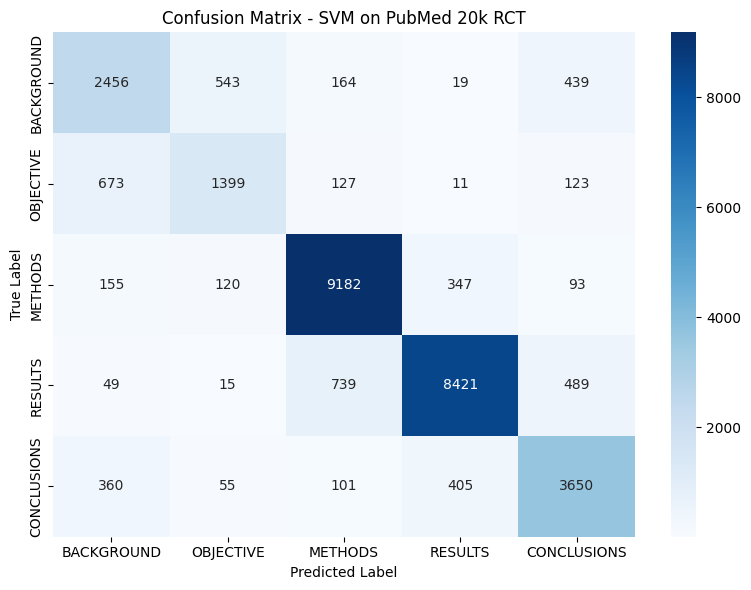

In [32]:
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt ="d", cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM on PubMed 20k RCT")
plt.tight_layout()
plt.show()

In [15]:
test_df["predicted"] = y_pred
errors = test_df[test_df["target"] != test_df["predicted"]]
errors[["abstract_text", "target", "predicted"]].head(10)

,abstract_text,target,predicted
1,A post hoc analysis was conducted with the use...,RESULTS,METHODS
2,Liver function tests ( LFTs ) were measured at...,RESULTS,METHODS
7,Abnormal LFTs are common in the ADHF populatio...,CONCLUSIONS,BACKGROUND
9,Minimally invasive endovascular aneurysm repai...,BACKGROUND,OBJECTIVE
10,The aim of this study was to analyse the cost-...,BACKGROUND,OBJECTIVE
20,Nor was EVAR superior regarding cost-utility .,RESULTS,CONCLUSIONS
23,This study investigated whether oxytocin can a...,METHODS,OBJECTIVE
27,Oxytocin reduced the difference between HSA an...,RESULTS,CONCLUSIONS
29,The biological mechanisms by which oxytocin ma...,RESULTS,CONCLUSIONS
42,Diesel exhaust induced acute adverse effects s...,CONCLUSIONS,BACKGROUND


In [17]:
feature_names = np.array(vectorizer.get_feature_names_out())

for i, label in enumerate(model.classes_):
    top_features = np.argsort(model.coef_[i])[-20:]
    print(f"\nTop features for class: {label}")
    print(feature_names[top_features])


Top features for class: BACKGROUND
['word__factors with' 'word__result from' 'word__guidelines recommend'
 'word__conducted to' 'word__theoretically' 'word__present the'
 'char__ ( ' 'word__trial showed' 'word__we previously' 'word__with osa'
 'word__from patient' 'word__was funded' 'char__ to d' 'word__is'
 'word__was designed' 'char__ to' 'char__ntr' 'char__ to c' 'char__ to e'
 'char__ to ']

Top features for class: CONCLUSIONS
['word__has no' 'word__our data' 'word__compared to'
 'word__two conditions' 'word__our' 'word__is feasible'
 'word__first randomised' 'word__was common' 'word__should'
 'word__enabled' 'word__alvimopan' 'word__further studies'
 'word__was effective' 'word__be considered' 'char__( cli' 'word__rct to'
 'char__ to e' 'word__we recommend' 'char__ to' 'char__ to ']

Top features for class: METHODS
['char__ to c' 'word__will' 'word__were calculated' 'char__ y '
 'char__ to e' 'char__ no ' 'word__patients affected' 'word__was used'
 'word__we used' 'word__measure 

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,6),
    min_df=3,
    max_df=0.9
)

In [21]:
from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1,3),
    min_df=3,
    max_df=0.9
)

combined_features = FeatureUnion([
    ("word_tfidf", word_vectorizer),
    ("char_tfidf", char_vectorizer)
])

model = Pipeline([
    ("features", combined_features),
    ("clf", LinearSVC())
])

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(model, param_grid, cv=5, scoring="f1_macro")
grid.fit(train_df['abstract_text'], y_train)

print(grid.best_params_)

{'clf__C': 0.1}


In [25]:
train_df["target"].value_counts()

target
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64

In [28]:
y_pred = grid.predict(test_df['abstract_text'])

print(classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

  BACKGROUND     0.6798    0.6625    0.6710      3621
 CONCLUSIONS     0.7675    0.7604    0.7640      4571
     METHODS     0.8703    0.9386    0.9032      9897
   OBJECTIVE     0.7083    0.5392    0.6123      2333
     RESULTS     0.8946    0.8867    0.8906      9713

    accuracy                         0.8308     30135
   macro avg     0.7841    0.7575    0.7682     30135
weighted avg     0.8271    0.8308    0.8276     30135



In [33]:
from sklearn.svm import LinearSVC

model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC(class_weight="balanced"))
])

In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["target"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["target"]
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{'BACKGROUND': np.float64(1.657292769365306), 'CONCLUSIONS': np.float64(1.3253828032979977), 'METHODS': np.float64(0.6066753154853166), 'OBJECTIVE': np.float64(2.6019221041982803), 'RESULTS': np.float64(0.6213310786326851)}


In [35]:
LinearSVC(class_weight=class_weights)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{'BACKGROUND': np.float64(1.657292769365306), 'CONCLUSIONS': np.float64(1.3253828032979977), 'METHODS': np.float64(0.6066753154853166), 'OBJECTIVE': np.float64(2.6019221041982803), ...}"
,verbose,0
,random_state,None


In [36]:
min_count = train_df["target"].value_counts().min()

balanced_df = (
    train_df
    .groupby("target")
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

C:\Users\Shyam\AppData\Local\Temp\ipykernel_20128\3910974517.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


In [40]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(
    train_df["abstract_text"].values.reshape(-1,1),
    train_df["target"]
)

X_resampled = X_resampled.flatten()

In [67]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        min_df=3,
        max_df=0.9
    )),
    ("clf", LinearSVC(
        C=0.1,
        class_weight="balanced"
    ))
])

In [68]:
pipeline.fit(X_resampled, y_resampled)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [69]:
y_pred = pipeline.predict(test_df['abstract_text'])

print(classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

  BACKGROUND     0.6687    0.6460    0.6571      3621
 CONCLUSIONS     0.7363    0.7744    0.7549      4571
     METHODS     0.8830    0.9148    0.8986      9897
   OBJECTIVE     0.6395    0.6014    0.6198      2333
     RESULTS     0.8977    0.8670    0.8821      9713

    accuracy                         0.8215     30135
   macro avg     0.7650    0.7607    0.7625     30135
weighted avg     0.8209    0.8215    0.8209     30135



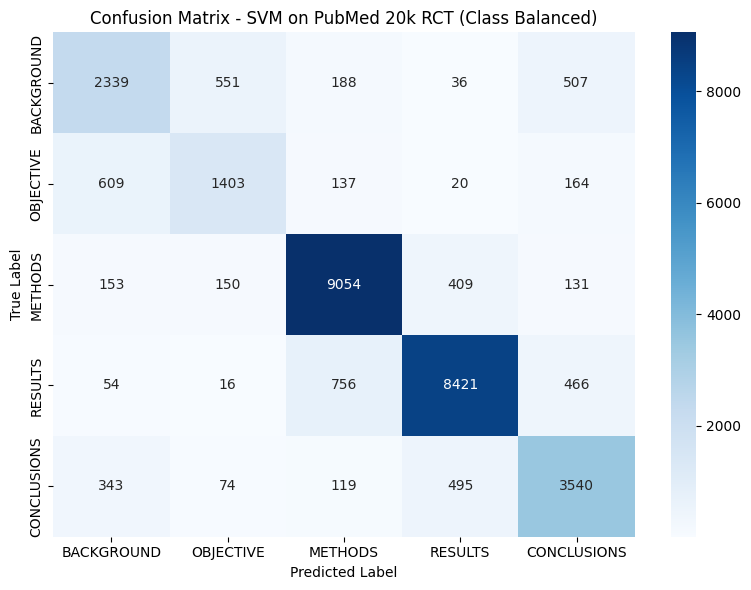

In [70]:
labels = ["BACKGROUND", "OBJECTIVE", "METHODS", "RESULTS", "CONCLUSIONS"]
cm = confusion_matrix(y_test, y_pred, labels = labels)
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt ="d", cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM on PubMed 20k RCT (Class Balanced)")
plt.tight_layout()
plt.show()